In [1]:
import os, csv
import numpy as np
import torch
import matplotlib.pyplot as plt

from utils.load_and_clean_real_data import load_and_clean_real_data
from utils.dataclass import TimeSeriesInferenceDataset

# ---- paths ----
DATA_PATH = "synthetic_data/synthetic_data_TL_seed10.csv"
KAPPA_NPZ = "synthetic_data/kappa_samples_Exp1_4gauss.npz"

CUTOFF = 300
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ---- truth (synthetic generation) ----
ALPHA_TRUE = 0.05
MU_TRUE    = 0.5
D_TRUE     = 0.12

truth = (ALPHA_TRUE, MU_TRUE, D_TRUE)

# ---- 1D grids ----
ALPHAS = np.linspace(0.0, 1/4, 26)[1:]
MUS    = np.linspace(0.2, 1.5, 26)[1:]
DS     = np.linspace(0.0, 0.2, 26)[1:]

DEVICE: cuda


In [2]:
print("allocated GiB:", torch.cuda.memory_allocated()/1024**3)
print("reserved  GiB:", torch.cuda.memory_reserved()/1024**3)

allocated GiB: 4.76837158203125e-07
reserved  GiB: 0.001953125


In [3]:
torch.manual_seed(15)
np.random.seed(15)

df = load_and_clean_real_data(DATA_PATH, cutoff=CUTOFF)
ts     = torch.tensor(df["Day"].values * 24)       # hours
counts = torch.tensor(df["Counts"].values)
dils   = torch.tensor(df["Dilution"].values)

kappa_np = np.load(KAPPA_NPZ)["kappa_samples"]

dataset = TimeSeriesInferenceDataset(
    ts=ts,
    counts=counts,
    dils=dils,
    kappa_samples=kappa_np,
    cutoff=CUTOFF,
    t_switch=24.0,
    rho=0.1,
    device=DEVICE,
)

print(f"Loaded dataset with {dataset.ndatapoints} points; timepoints={len(dataset.times)}")


[WARN] Missing columns skipped: CFU_2
[INFO] Using dilutions: [22, 222, 2222]
[INFO] Loaded 375 rows from synthetic_data/synthetic_data_TL_seed10.csv
[INFO] Retained 375 rows with valid CFU entries.
[INFO] Dropped 0 rows with no valid CFU values at any dilution.
Dataset loaded: 375 points, 5 timepoints.
Loaded dataset with 375 points; timepoints=5


In [4]:
# Likelihood wrapper

def loglike_alpha_mu_d(dataset, alpha, mu, d):
    alpha = torch.as_tensor(alpha, device=dataset.device, dtype=torch.float32)
    mu    = torch.as_tensor(mu,    device=dataset.device, dtype=torch.float32)
    d     = torch.as_tensor(d,     device=dataset.device, dtype=torch.float32)
    theta_phys = torch.stack([alpha, mu, d])
    with torch.no_grad():
        ll = dataset.loglike(theta_phys)
    return float(ll.detach().cpu())


In [5]:
# Run one 1D sweep (generic helper)
def run_1d(which: str, grid: np.ndarray, truth):
    a0, m0, d0 = truth
    xs = []
    lls = []
    best = (-np.inf, None)  # (ll, x)

    for x in grid:
        a, m, d = a0, m0, d0
        if which == "alpha": a = float(x)
        elif which == "mu":  m = float(x)
        elif which == "d":   d = float(x)
        else:
            raise ValueError("which must be one of: alpha, mu, d")

        ll = loglike_alpha_mu_d(dataset, a, m, d)
        print(ll)
        xs.append(float(x))
        lls.append(ll)
        if ll > best[0]:
            best = (ll, float(x))

    return np.array(xs), np.array(lls), best


In [6]:
x_a, ll_a, best_a = run_1d("alpha", ALPHAS, truth)
x_m, ll_m, best_m = run_1d("mu",    MUS,    truth)
x_d, ll_d, best_d = run_1d("d",     DS,     truth)

print("Truth:", truth)
print("[alpha] best ll:", best_a[0], "at alpha =", best_a[1])
print("[mu]    best ll:", best_m[0], "at mu    =", best_m[1])
print("[d]     best ll:", best_d[0], "at d     =", best_d[1])


-1869.7395978141867
-1756.1144383901851
-1708.3461566733442
-1691.8222640285062
-1689.2114384643971
-1696.703640614232
-1709.5750532351321
-1727.1647086477396
-1745.0618635535818
-1769.1520044311233
-1793.2925339088865
-1815.8770462031334
-1841.0777838722993
-1862.200199028976
-1890.202614974702
-1927.984243955612
-1957.4448943482248
-1975.550810338625
-2000.382522209491
-2033.6456831260734
-2062.2722445436257
-2090.809332102127
-2115.4125384347035
-2135.4839325968696
-2163.88842911964
-3393.6825219506754
-2541.2094554764817
-1754.3359517637914
-1702.9769321300917
-1688.1215116070853
-1690.135396345279
-1696.6060071468778
-1702.1712928099814
-1709.253498395395
-1714.1734037351837
-1719.968136896411
-1723.443526433771
-1728.0072171848299
-1731.4515704207577
-1734.5469139544573
-1738.3589107027178
-1739.9677219519654
-1743.2804005514442
-1746.3886417524773
-1749.1511852409712
-1750.1907179208301
-1753.5696456721669
-1754.3401400611606
-1756.035640683403
-1758.3306530134305
-1713.74505617

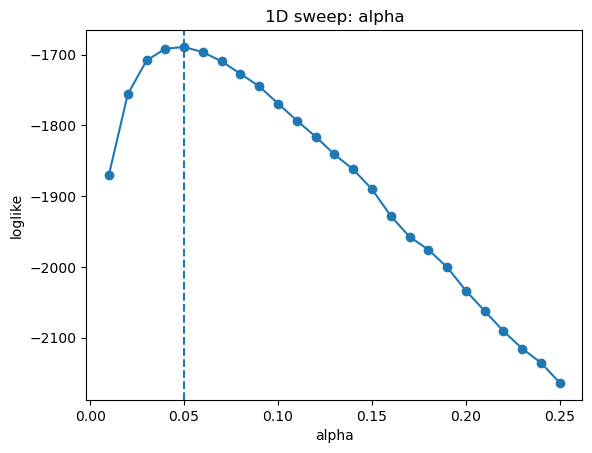

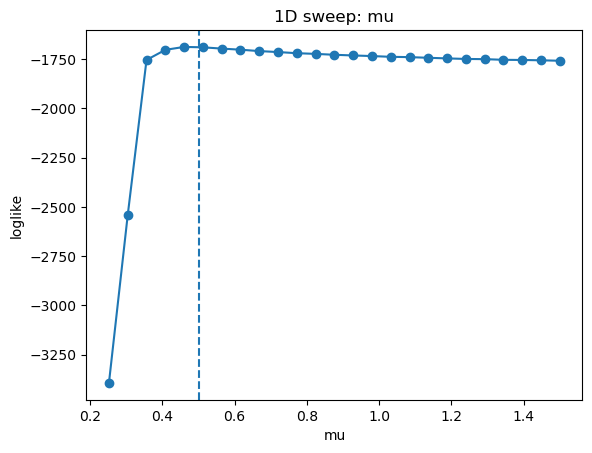

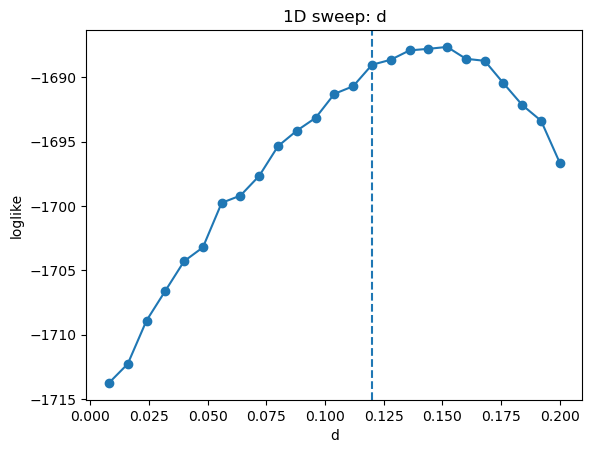

In [7]:
# Plot results
def plot_1d(x, ll, truth_val, xlabel):
    plt.figure()
    plt.plot(x, ll, marker="o")
    plt.axvline(truth_val, linestyle="--")
    plt.xlabel(xlabel)
    plt.ylabel("loglike")
    plt.title(f"1D sweep: {xlabel}")
    plt.show()

plot_1d(x_a, ll_a, ALPHA_TRUE, "alpha")
plot_1d(x_m, ll_m, MU_TRUE,    "mu")
plot_1d(x_d, ll_d, D_TRUE,     "d")


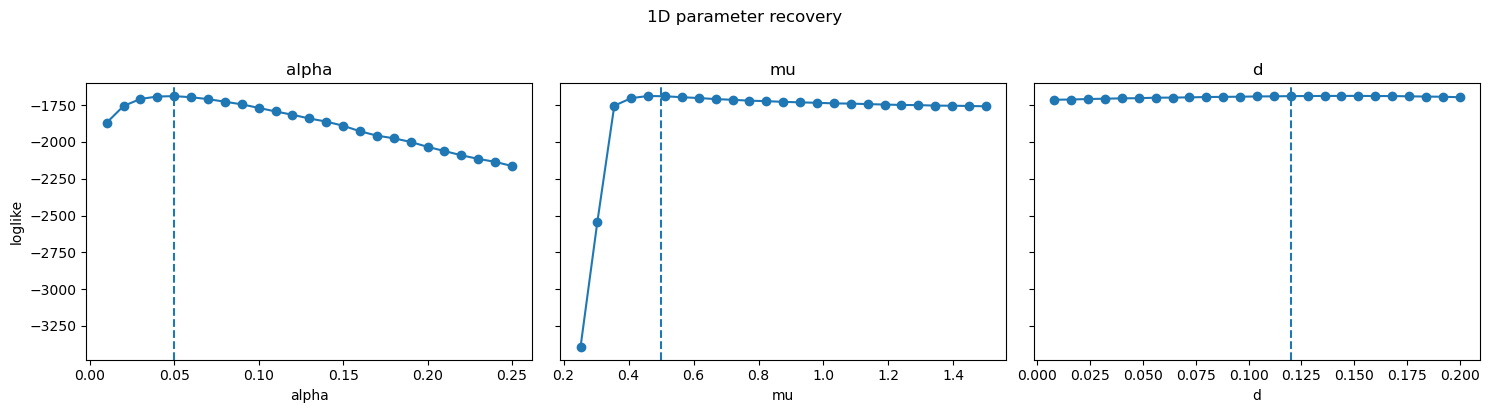

In [8]:
def plot_1d_row(xs, lls, truths, xlabels):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, x, ll, truth, xlabel in zip(axes, xs, lls, truths, xlabels):
        ax.plot(x, ll, marker="o")
        ax.axvline(truth, linestyle="--")
        ax.set_xlabel(xlabel)
        ax.set_title(f"{xlabel}")

    axes[0].set_ylabel("loglike")
    fig.suptitle("1D parameter recovery", y=1.02)
    plt.tight_layout()
    plt.show()

plot_1d_row(
    xs=[x_a, x_m, x_d],
    lls=[ll_a, ll_m, ll_d],
    truths=[ALPHA_TRUE, MU_TRUE, D_TRUE],
    xlabels=["alpha", "mu", "d"],
)


In [9]:
import pandas as pd

os.makedirs("recovery_tests/grid_TL_seed10", exist_ok=True)

pd.DataFrame({"alpha": x_a, "loglike": ll_a}).to_csv("recovery_tests/grid_TL_seed10/alpha_only.csv", index=False)
pd.DataFrame({"mu":    x_m, "loglike": ll_m}).to_csv("recovery_tests/grid_TL_seed10/mu_only.csv",    index=False)
pd.DataFrame({"d":     x_d, "loglike": ll_d}).to_csv("recovery_tests/grid_TL_seed10/d_only.csv",     index=False)

print("Saved CSVs in recovery_tests/grid_TL_seed10/")


Saved CSVs in recovery_tests/grid_TL_seed10/


In [10]:
import time
import torch

def time_loglike(dataset, theta, label=""):
    # Ensure any previous GPU work is done
    if dataset.device.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    ll = dataset.loglike(theta)

    # Force completion so timing is real
    if dataset.device.type == "cuda":
        torch.cuda.synchronize()

    dt = time.perf_counter() - t0
    print(f"{label} loglike took {dt:.3f} s  (value={float(ll.detach().cpu()):.6g})", flush=True)
    return ll, dt


In [11]:
theta = torch.tensor(
    [ALPHA_TRUE, MU_TRUE, D_TRUE],
    device=dataset.device,
    dtype=dataset.kappa_samples.dtype,
)

ll, dt = time_loglike(dataset, theta, label="truth")


truth loglike took 34.657 s  (value=-1689.12)


In [12]:
for i in range(3):
    ll, dt = time_loglike(dataset, theta, label=f"run {i}")


run 0 loglike took 32.287 s  (value=-1689.53)
run 1 loglike took 32.640 s  (value=-1688.82)
run 2 loglike took 33.481 s  (value=-1688.6)


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_1d_row_from_csv(
    csv_paths,
    truths,
    xlabels=None,
):
    """
    Plot 1D likelihood curves from CSVs.

    Parameters
    ----------
    csv_paths : list[str | Path]
        Paths to CSV files, each with columns [param, loglike]
    truths : dict
        Mapping from parameter name -> true value
        e.g. {"alpha": 0.05, "mu": 0.5, "d": 0.02}
    xlabels : list[str], optional
        Custom x-axis labels; defaults to parameter names
    """

    fig, axes = plt.subplots(1, len(csv_paths), figsize=(5 * len(csv_paths), 4), sharey=True)

    if len(csv_paths) == 1:
        axes = [axes]

    for i, (ax, csv_path) in enumerate(zip(axes, csv_paths)):
        df = pd.read_csv(csv_path)

        # Infer parameter column (anything not 'loglike')
        param_cols = [c for c in df.columns if c != "loglike"]
        if len(param_cols) != 1:
            raise ValueError(f"{csv_path} must have exactly one parameter column")

        param = param_cols[0]

        x = df[param].values
        ll = df["loglike"].values

        ax.plot(x, ll, marker="o")
        ax.axvline(truths[param], linestyle="--")

        xlabel = xlabels[i] if xlabels is not None else param
        ax.set_xlabel(xlabel)
        ax.set_title(param)

    axes[0].set_ylabel("loglike")
    fig.suptitle("1D parameter recovery", y=1.02)
    plt.tight_layout()
    plt.show()


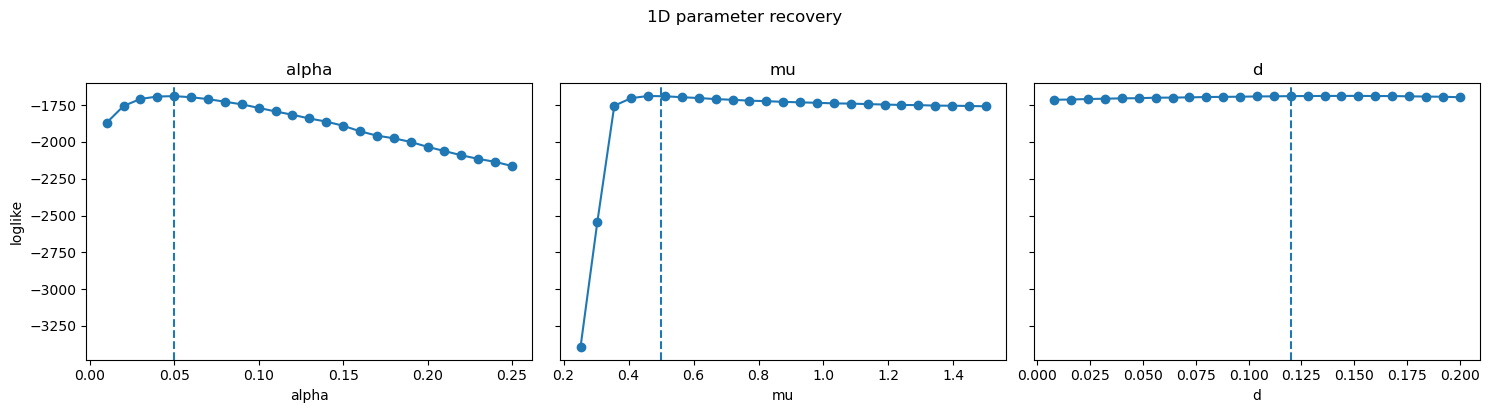

In [14]:
plot_1d_row_from_csv(
    csv_paths=[
        "recovery_tests/grid_TL_seed10/alpha_only.csv",
        "recovery_tests/grid_TL_seed10/mu_only.csv",
        "recovery_tests/grid_TL_seed10/d_only.csv",
    ],
    truths={
        "alpha": 0.05,
        "mu": 0.5,
        "d": 0.12,
    },
)
